In [1]:
import json
from pathlib import Path

ASSEMBLY = "7778_3a9748b3"
DATA = Path("data") / ASSEMBLY
json_path = DATA / "assembly.json"

data = json.loads(json_path.read_text())

tree_root = data["tree"]["root"]
print("tree root keys:", list(tree_root.keys())[:3])

occ_id = list(tree_root.keys())[0]
occ = data["occurrences"][occ_id]
print("\noccurrence sample:", occ_id)
print("  keys:", list(occ.keys()))
print("  is_visible:", occ.get("is_visible"))
print("  transform keys:", list(occ.get("transform", {}).keys()))
print("  bodies:", list(occ.get("bodies", {}).keys())[:2])

# посмотрим есть ли вложенные дети
children = tree_root[occ_id]
print("\nchildren type:", type(children), "len:", len(children) if children else 0)

tree root keys: ['72780126-0600-11ec-85f1-020dc2b44123', '728631ec-0600-11ec-9fb6-020dc2b44123', '72b16090-0600-11ec-bcca-020dc2b44123']

occurrence sample: 72780126-0600-11ec-85f1-020dc2b44123
  keys: ['name', 'type', 'component', 'is_grounded', 'is_visible', 'timeline_index', 'physical_properties', 'transform', 'bodies']
  is_visible: True
  transform keys: ['origin', 'x_axis', 'y_axis', 'z_axis']
  bodies: ['717474a8-0600-11ec-bd40-020dc2b44123', '7174c2c6-0600-11ec-92ac-020dc2b44123']

children type: <class 'dict'> len: 0


In [2]:
import torch

def parse_transform(t):
    o, x, y, z = t["origin"], t["x_axis"], t["y_axis"], t["z_axis"]
    return torch.tensor([
        [x["x"], y["x"], z["x"], o["x"]],
        [x["y"], y["y"], z["y"], o["y"]],
        [x["z"], y["z"], z["z"], o["z"]],
        [0., 0., 0., 1.]
    ], dtype=torch.float32)

# проверка
occ_id = list(data["occurrences"].keys())[0]
M = parse_transform(data["occurrences"][occ_id]["transform"])
print("transform shape:", M.shape)
print(M)
print("det:", torch.linalg.det(M[:3,:3]).item())  # должен быть ~1.0


transform shape: torch.Size([4, 4])
tensor([[ 9.7815e-01, -2.0791e-01,  0.0000e+00,  2.8310e+02],
        [ 2.0791e-01,  9.7815e-01,  0.0000e+00,  4.1412e+00],
        [ 0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])
det: 1.0000001192092896


In [3]:
from pytorch3d.io import load_obj

ASSEMBLY = "7778_3a9748b3"
DATA = Path("data") / ASSEMBLY

def load_and_transform(body_uuid, M):
    path = DATA / f"{body_uuid}.obj"
    verts, faces_idx, _ = load_obj(str(path), load_textures=False)
    faces = faces_idx.verts_idx  # (F, 3)
    ones = torch.ones(verts.shape[0], 1)
    verts_h = torch.cat([verts, ones], dim=1)  # (N, 4)
    verts_t = (M @ verts_h.T).T[:, :3]         # (N, 3)
    return verts_t, faces

# тест на первом body первого occurrence
occ = data["occurrences"][occ_id]
first_body = list(occ["bodies"].keys())[0]
verts_t, faces = load_and_transform(first_body, M)
print("body:", first_body)
print("verts:", verts_t.shape, "  min/max x:", verts_t[:,0].min().item(), verts_t[:,0].max().item())
print("faces:", faces.shape)


body: 717474a8-0600-11ec-bd40-020dc2b44123
verts: torch.Size([198, 3])   min/max x: 8.637359619140625 10.564727783203125
faces: torch.Size([396, 3])


In [4]:
occ = data["occurrences"][occ_id]
bodies = occ["bodies"]
print("bodies type:", type(bodies))
first_body_uuid = list(bodies.keys())[0]
print("body value:", bodies[first_body_uuid])


bodies type: <class 'dict'>
body value: {'is_visible': True}


In [5]:
from pytorch3d.io import load_obj
import torch
from pathlib import Path

ASSEMBLY = "7778_3a9748b3"
DATA = Path("data") / ASSEMBLY

def parse_transform(t):
    o, x, y, z = t["origin"], t["x_axis"], t["y_axis"], t["z_axis"]
    return torch.tensor([
        [x["x"], y["x"], z["x"], o["x"]],
        [x["y"], y["y"], z["y"], o["y"]],
        [x["z"], y["z"], z["z"], o["z"]],
        [0., 0., 0., 1.]
    ], dtype=torch.float32)

def load_and_transform(body_uuid, M):
    verts, faces_idx, _ = load_obj(str(DATA / f"{body_uuid}.obj"), load_textures=False)
    faces = faces_idx.verts_idx
    verts_h = torch.cat([verts, torch.ones(verts.shape[0], 1)], dim=1)
    return (M @ verts_h.T).T[:, :3], faces

def walk_tree(node, parent_M, data, results, label_counter):
    for occ_uuid, children in node.items():
        occ = data["occurrences"].get(occ_uuid)
        if occ is None or not occ.get("is_visible", True):
            continue
        full_M = parent_M @ parse_transform(occ["transform"])
        comp_name = data["components"].get(occ.get("component", ""), {}).get("name", "")
        for body_uuid, body_info in occ.get("bodies", {}).items():
            if not body_info.get("is_visible", True):
                continue
            path = DATA / f"{body_uuid}.obj"
            if not path.exists():
                continue
            try:
                verts, faces = load_and_transform(body_uuid, full_M)
            except Exception:
                continue
            if verts.shape[0] == 0 or faces.shape[0] == 0:
                continue
            results.append({
                "verts": verts, "faces": faces,
                "label": label_counter[0],
                "occ_uuid": occ_uuid, "body_uuid": body_uuid,
                "name": occ.get("name", ""), "component_name": comp_name
            })
            label_counter[0] += 1
        if isinstance(children, dict) and children:
            walk_tree(children, full_M, data, results, label_counter)

import json
data = json.loads((DATA / "assembly.json").read_text())
results = []
walk_tree(data["tree"]["root"], torch.eye(4), data, results, [1])

print(f"Instances: {len(results)}")
print(f"Labels: {results[0]['label']} .. {results[-1]['label']}")
print(f"First: {results[0]['name']}, verts={results[0]['verts'].shape}, faces={results[0]['faces'].shape}")


Instances: 167
Labels: 1 .. 167
First: FRAME - CARBON -> v48:1, verts=torch.Size([198, 3]), faces=torch.Size([396, 3])


In [6]:
import numpy as np
from pytorch3d.io import save_obj

OUTPUT = Path("output") / ASSEMBLY
OUTPUT.mkdir(parents=True, exist_ok=True)

all_verts, all_faces, all_labels = [], [], []
v_offset = 0

for r in results:
    all_verts.append(r["verts"])
    all_faces.append(r["faces"] + v_offset)
    all_labels.append(torch.full((r["faces"].shape[0],), r["label"], dtype=torch.int32))
    v_offset += r["verts"].shape[0]

verts_cat = torch.cat(all_verts, dim=0)
faces_cat = torch.cat(all_faces, dim=0)
labels_np = torch.cat(all_labels, dim=0).numpy()

# сохраняем
save_obj(str(OUTPUT / "combined_mesh.obj"), verts_cat, faces_cat)
np.save(OUTPUT / "face_labels.npy", labels_np)

instance_map = {
    str(r["label"]): {
        "occurrence_uuid": r["occ_uuid"],
        "body_uuid": r["body_uuid"],
        "name": r["name"],
        "component_name": r["component_name"]
    }
    for r in results
}
(OUTPUT / "instance_map.json").write_text(json.dumps(instance_map, indent=2))

print(f"Vertices: {verts_cat.shape}")
print(f"Faces:    {faces_cat.shape}")
print(f"Labels:   unique={np.unique(labels_np).shape[0]}, max={labels_np.max()}")
print(f"Saved to: {OUTPUT}")


Vertices: torch.Size([142077, 3])
Faces:    torch.Size([283814, 3])
Labels:   unique=167, max=167
Saved to: output/7778_3a9748b3


In [12]:
import json
import numpy as np
from pathlib import Path
from pytorch3d.io import load_obj

ASSEMBLY = "16550_e88d6986"
DATA = Path("data") / ASSEMBLY
OUTPUT = Path("output") / ASSEMBLY

# Загружаем сохранённый combined_mesh
verts_saved, faces_saved_idx, _ = load_obj(str(OUTPUT / "combined_mesh.obj"), load_textures=False)
faces_saved = faces_saved_idx.verts_idx
labels = np.load(OUTPUT / "face_labels.npy")
inst_map = json.loads((OUTPUT / "instance_map.json").read_text())

print("=== Сохранено в output/ ===")
print(f"combined_mesh.obj:  {verts_saved.shape[0]} vертексов, {faces_saved.shape[0]} граней")
print(f"face_labels.npy:    {labels.shape[0]} меток, unique={np.unique(labels).shape[0]}, min={labels.min()}, max={labels.max()}")
print(f"instance_map.json:  {len(inst_map)} инстансов")
print()

# Проверяем суммы по каждому инстансу
print("=== Проверка per-instance ===")
for lbl in [1, 2, 3]:
    count = (labels == lbl).sum()
    name = inst_map[str(lbl)]["name"]
    print(f"  label={lbl}: {count} граней  ({name})")

# Считаем сколько граней у каждого тела НАПРЯМУЮ из OBJ
print()
print("=== Прямой подсчёт исходных OBJ ===")
total_faces_raw = 0
for k, v in list(inst_map.items())[:3]:
    body_path = DATA / f"{v['body_uuid']}.obj"
    _, fi, _ = load_obj(str(body_path), load_textures=False)
    f = fi.verts_idx.shape[0]
    total_faces_raw += f
    print(f"  label={k}: {f} граней  ({v['name']})")


FileNotFoundError: [Errno 2] No such file or directory: 'output/16550_e88d6986/combined_mesh.obj'

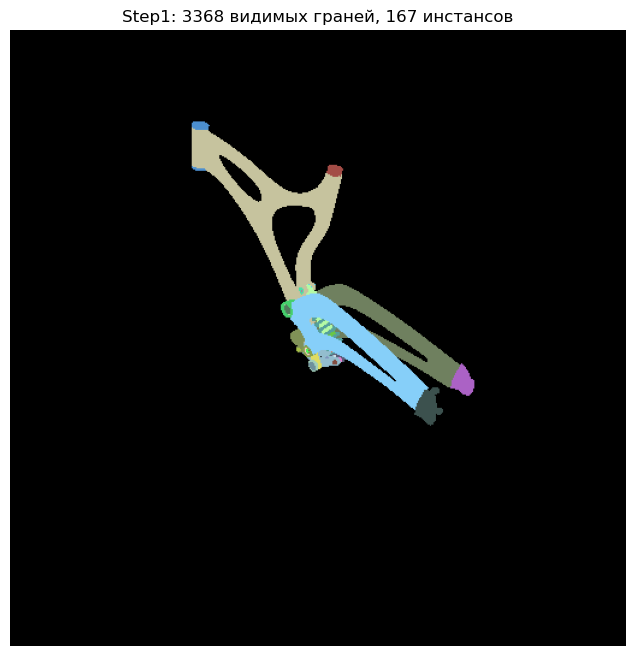

In [8]:
import torch
import matplotlib.pyplot as plt
from pytorch3d.renderer import (
    FoVPerspectiveCameras, RasterizationSettings,
    MeshRasterizer, look_at_view_transform
)
from pytorch3d.structures import Meshes

# Случайные цвета для каждого label
rng = np.random.default_rng(42)
n_labels = labels.max() + 1
colors = rng.integers(60, 255, size=(n_labels, 3), dtype=np.uint8)
colors[0] = [30, 30, 30]  # фон

# Карта face_id → цвет RGB float
face_colors_rgb = colors[labels] / 255.0  # (F, 3)

# Строим Meshes с face colors через vertex colors (интерполяция)
# Упрощение: красим через pix_to_face после растеризации
device = torch.device("cpu")
verts_t = verts_saved.to(device)
faces_t = faces_saved.to(device)
mesh = Meshes(verts=[verts_t], faces=[faces_t])

center = verts_t.mean(dim=0)
radius = (verts_t - center).norm(dim=1).max().item()
dist = radius / np.tan(np.deg2rad(30))

R, T = look_at_view_transform(dist=dist*1.2, elev=30, azim=45, at=(center.tolist(),))
cameras = FoVPerspectiveCameras(device=device, R=R, T=T, fov=60)
raster = MeshRasterizer(cameras=cameras, raster_settings=RasterizationSettings(image_size=512, blur_radius=0.0, faces_per_pixel=1))
frags = raster(mesh)

pix = frags.pix_to_face[0, :, :, 0].numpy()  # (512, 512)

img = np.zeros((512, 512, 3), dtype=np.uint8)
valid = pix >= 0
img[valid] = (face_colors_rgb[pix[valid]] * 255).astype(np.uint8)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"Step1: {np.unique(pix[valid]).shape[0]} видимых граней, {len(inst_map)} инстансов")
plt.axis("off")
plt.show()


In [9]:
with open(DATA / "assembly.obj") as f:
    lines = f.readlines()[:50]
for l in lines:
    if l.startswith("#") or l.startswith("g ") or l.startswith("o "):
        print(l.strip())


# WaveFront *.obj file
# Vertices: 306578
# Triangles : 457522


In [13]:
from pathlib import Path
from pytorch3d.io import load_obj

DATA = Path("data/7778_3a9748b3")
total_v, total_f = 0, 0

for p in DATA.glob("*.obj"):
    if p.name == "assembly.obj":
        continue
    v, fi, _ = load_obj(str(p), load_textures=False)
    total_v += v.shape[0]
    total_f += fi.verts_idx.shape[0]

print(f"Всего OBJ файлов: {sum(1 for p in DATA.glob('*.obj') if p.name != 'assembly.obj')}")
print(f"Сумма вершин:    {total_v}")
print(f"Сумма граней:    {total_f}")
print()
print(f"combined_mesh:   142077 вершин, 283814 граней")
print(f"assembly.obj:    306578 вершин, 457522 граней")


Всего OBJ файлов: 77
Сумма вершин:    60297
Сумма граней:    120035

combined_mesh:   142077 вершин, 283814 граней
assembly.obj:    306578 вершин, 457522 граней


In [14]:
import json
from pathlib import Path

DATA = Path("data/16550_e88d6986")
data = json.loads((DATA / "assembly.json").read_text())

tree = data["tree"]["root"]
print("tree root keys:", list(tree.keys())[:3])
print("tree root len:", len(tree))

# смотрим первый occurrence
occ_id = list(tree.keys())[0]
occ = data["occurrences"].get(occ_id, {})
print("\nfirst occ keys:", list(occ.keys()))
print("is_visible:", occ.get("is_visible"))
print("has bodies:", "bodies" in occ, "| bodies:", list(occ.get("bodies", {}).keys())[:2])

# ищем хоть один body_uuid OBJ
body_ids = list(occ.get("bodies", {}).keys())
for bid in body_ids[:3]:
    p = DATA / f"{bid}.obj"
    print(f"  {bid}.obj exists: {p.exists()}")


tree root keys: []
tree root len: 0


IndexError: list index out of range

In [15]:
import torch
import numpy as np
from pathlib import Path
from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.renderer import (
    FoVPerspectiveCameras, RasterizationSettings,
    MeshRasterizer, look_at_view_transform
)

ASSEMBLY = "16550_e88d6986"   # маленькая, быстрая
base = Path("preprocessed_data") / ASSEMBLY

verts, faces_idx, _ = load_obj(str(base / "combined_mesh.obj"), load_textures=False)
faces = faces_idx.verts_idx
mesh = Meshes(verts=[verts], faces=[faces])

center = verts.mean(dim=0)
radius = (verts - center).norm(dim=1).max().item()
dist = radius / np.tan(np.deg2rad(30))

N = 100
phi = (1 + 5**0.5) / 2
i = torch.arange(N, dtype=torch.float32)
elev_arr = (torch.arcsin(1 - 2*i/N) * 180 / torch.pi).tolist()
azim_arr = ((i * 360 / phi) % 360).tolist()

covered = torch.zeros(faces.shape[0], dtype=torch.bool)
raster_cfg = RasterizationSettings(image_size=128, blur_radius=0.0, faces_per_pixel=1)

for k in range(N):
    R, T = look_at_view_transform(
        dist=dist, elev=elev_arr[k], azim=azim_arr[k], at=(center.tolist(),)
    )
    frags = MeshRasterizer(
        cameras=FoVPerspectiveCameras(R=R, T=T, fov=60),
        raster_settings=raster_cfg
    )(mesh)
    pix = frags.pix_to_face[0, :, :, 0]
    covered[pix[pix >= 0]] = True

face_labels = np.load(base / "face_labels.npy")
outer_mask = covered.numpy()
outer_labels = face_labels.copy()
outer_labels[~outer_mask] = 0

np.save(base / "outer_face_mask.npy", outer_mask)
np.save(base / "outer_face_labels.npy", outer_labels)

print(f"Total faces:  {faces.shape[0]}")
print(f"Outer faces:  {outer_mask.sum()}  ({outer_mask.mean():.1%})")
print(f"Hidden faces: {(~outer_mask).sum()}")


Total faces:  8610
Outer faces:  7112  (82.6%)
Hidden faces: 1498


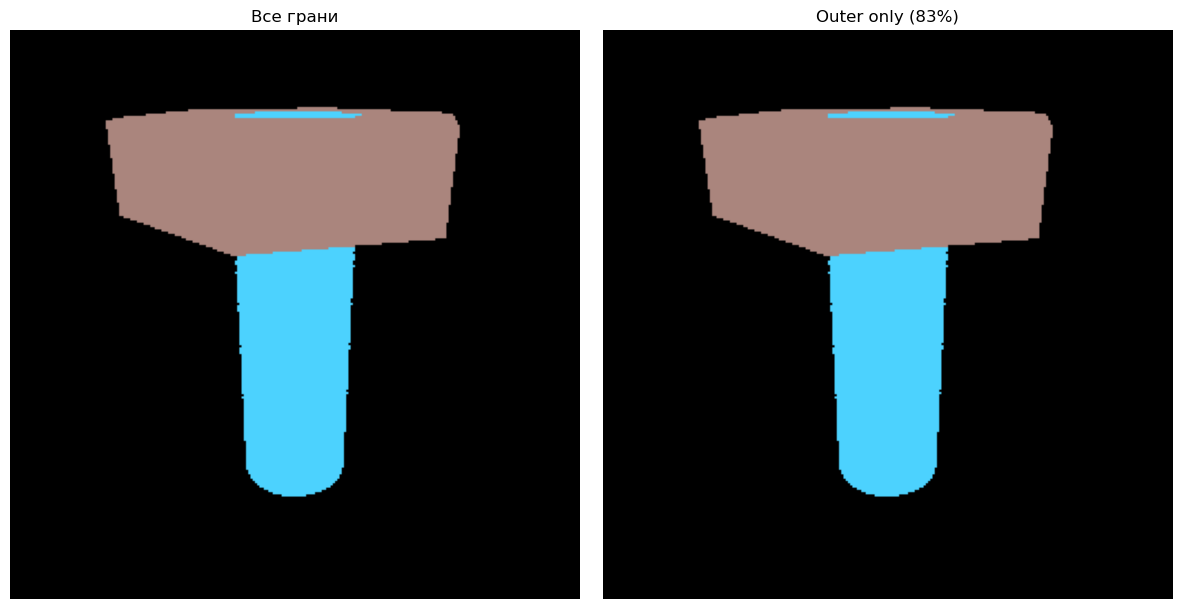

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.renderer import (
    FoVPerspectiveCameras, RasterizationSettings,
    MeshRasterizer, look_at_view_transform
)

ASSEMBLY = "16550_e88d6986"
base = Path("preprocessed_data") / ASSEMBLY

verts, faces_idx, _ = load_obj(str(base / "combined_mesh.obj"), load_textures=False)
faces = faces_idx.verts_idx
face_labels = np.load(base / "face_labels.npy")
outer_mask = np.load(base / "outer_face_mask.npy")

rng = np.random.default_rng(42)
n = face_labels.max() + 1
colors = rng.integers(60, 255, size=(n, 3), dtype=np.uint8)

center = verts.mean(dim=0)
radius = (verts - center).norm(dim=1).max().item()
dist = radius / __import__("math").tan(__import__("math").radians(30))

def render_colored(mask, title, ax):
    face_colors_rgb = np.zeros((faces.shape[0], 3), dtype=np.uint8)
    face_colors_rgb[mask] = colors[face_labels[mask]]
    face_colors_rgb[~mask] = [40, 40, 40]  # скрытые — тёмные

    mesh = Meshes(verts=[verts], faces=[faces])
    R, T = look_at_view_transform(dist=dist*1.2, elev=25, azim=45, at=(center.tolist(),))
    frags = MeshRasterizer(
        cameras=FoVPerspectiveCameras(R=R, T=T, fov=60),
        raster_settings=RasterizationSettings(image_size=256, blur_radius=0.0, faces_per_pixel=1)
    )(mesh)
    pix = frags.pix_to_face[0, :, :, 0].numpy()
    img = np.zeros((256, 256, 3), dtype=np.uint8)
    valid = pix >= 0
    img[valid] = face_colors_rgb[pix[valid]]
    ax.imshow(img); ax.set_title(title); ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
render_colored(np.ones(faces.shape[0], dtype=bool), "Все грани", axes[0])
render_colored(outer_mask, f"Outer only ({outer_mask.mean():.0%})", axes[1])
plt.tight_layout()
plt.show()


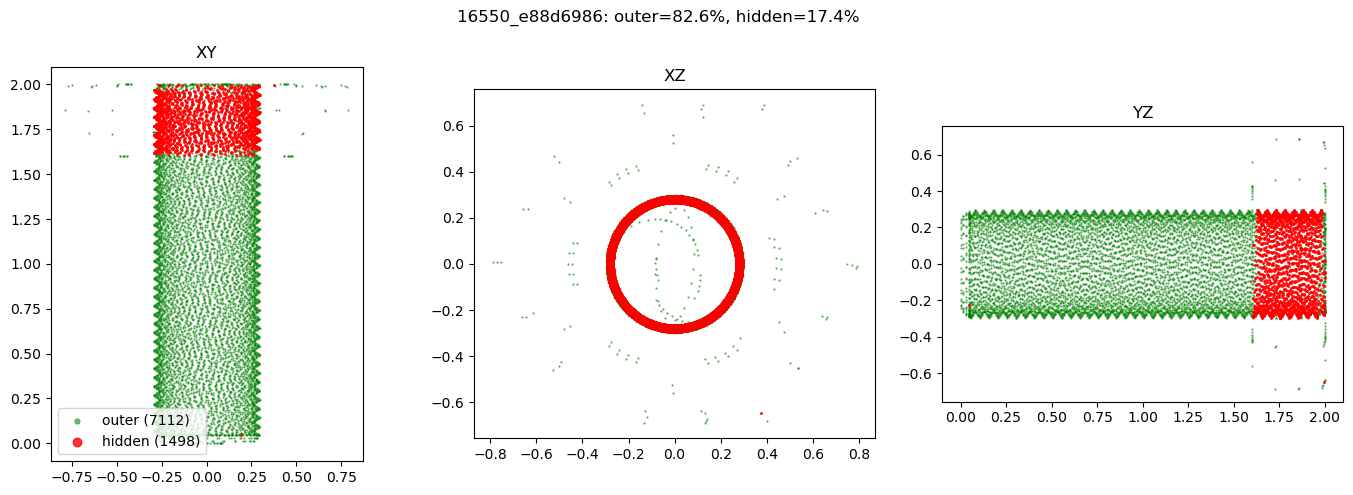

In [17]:
from pytorch3d.io import load_obj
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base = Path("preprocessed_data/16550_e88d6986")
verts, fi, _ = load_obj(str(base/"combined_mesh.obj"), load_textures=False)
faces = fi.verts_idx.numpy()
outer = np.load(base/"outer_face_mask.npy")

centroids = verts.numpy()[faces].mean(axis=1)  # (F, 3)

fig = plt.figure(figsize=(14, 5))

# вид XY
ax1 = fig.add_subplot(131)
ax1.scatter(centroids[outer, 0], centroids[outer, 1], s=0.5, c="green", alpha=0.5, label=f"outer ({outer.sum()})")
ax1.scatter(centroids[~outer, 0], centroids[~outer, 1], s=1.5, c="red", alpha=0.8, label=f"hidden ({(~outer).sum()})")
ax1.set_title("XY"), ax1.set_aspect("equal"), ax1.legend(markerscale=5)

# вид XZ
ax2 = fig.add_subplot(132)
ax2.scatter(centroids[outer, 0], centroids[outer, 2], s=0.5, c="green", alpha=0.5)
ax2.scatter(centroids[~outer, 0], centroids[~outer, 2], s=1.5, c="red", alpha=0.8)
ax2.set_title("XZ"), ax2.set_aspect("equal")

# вид YZ
ax3 = fig.add_subplot(133)
ax3.scatter(centroids[outer, 1], centroids[outer, 2], s=0.5, c="green", alpha=0.5)
ax3.scatter(centroids[~outer, 1], centroids[~outer, 2], s=1.5, c="red", alpha=0.8)
ax3.set_title("YZ"), ax3.set_aspect("equal")

plt.suptitle(f"16550_e88d6986: outer={outer.mean():.1%}, hidden={(~outer).mean():.1%}")
plt.tight_layout()
plt.show()


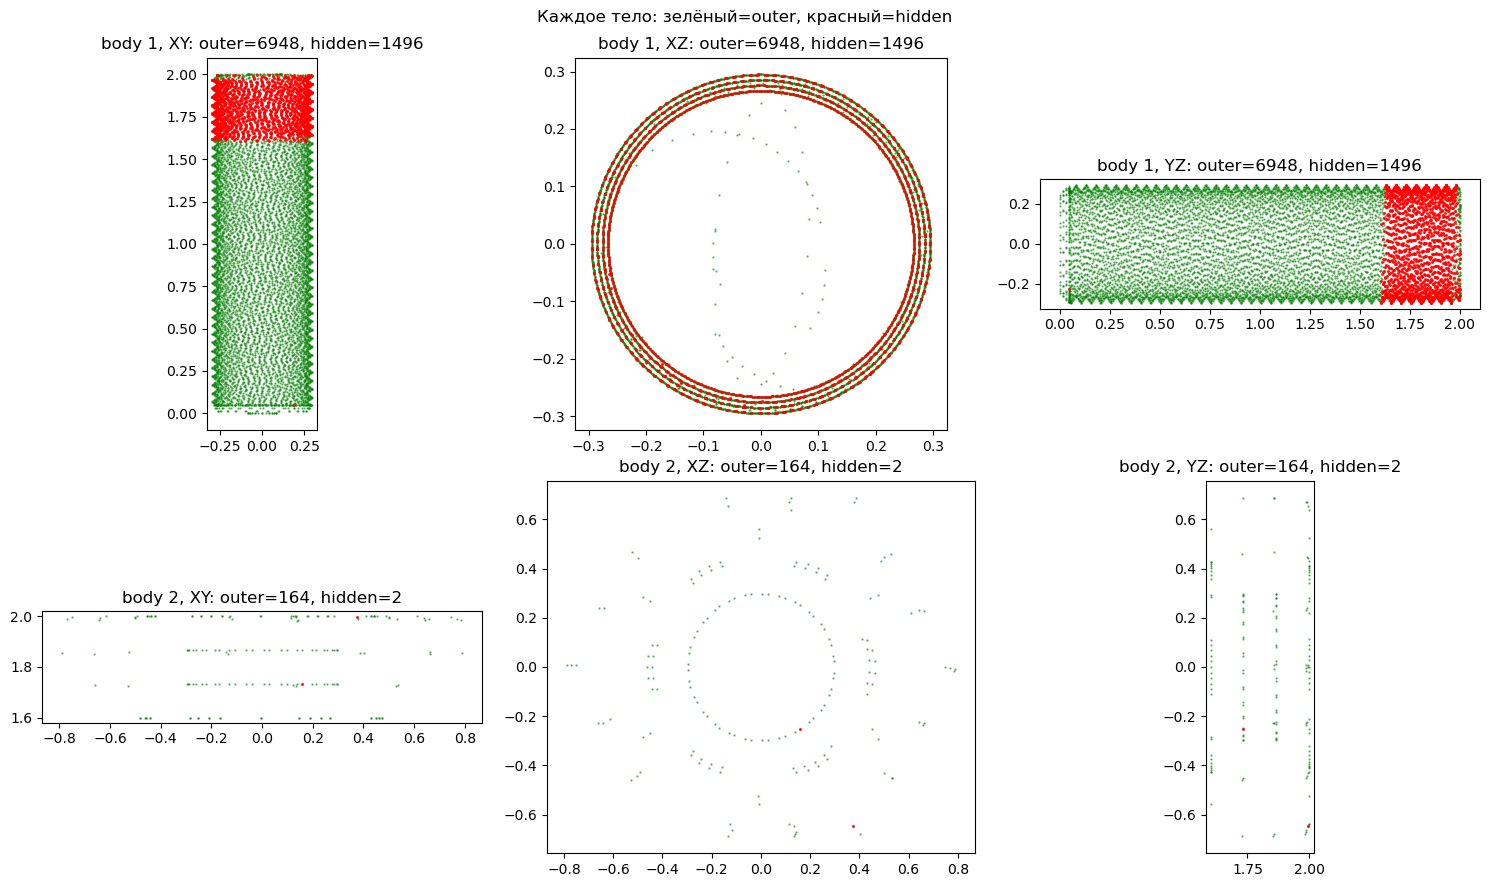

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pytorch3d.io import load_obj

base = Path("preprocessed_data/16550_e88d6986")
verts, fi, _ = load_obj(str(base/"combined_mesh.obj"), load_textures=False)
faces = fi.verts_idx.numpy()
face_labels = np.load(base/"face_labels.npy")
outer = np.load(base/"outer_face_mask.npy")
centroids = verts.numpy()[faces].mean(axis=1)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Каждое тело: зелёный=outer, красный=hidden")

for row, lbl in enumerate([1, 2]):
    mask_lbl = face_labels == lbl
    n_outer = (mask_lbl & outer).sum()
    n_hidden = (mask_lbl & ~outer).sum()
    views = [("XY", 0, 1), ("XZ", 0, 2), ("YZ", 1, 2)]
    for col, (title, xi, yi) in enumerate(views):
        ax = axes[row][col]
        pts_out = centroids[mask_lbl & outer]
        pts_hid = centroids[mask_lbl & ~outer]
        ax.scatter(pts_out[:,xi], pts_out[:,yi], s=0.5, c="green", alpha=0.5)
        ax.scatter(pts_hid[:,xi], pts_hid[:,yi], s=1.5, c="red", alpha=0.8)
        ax.set_title(f"body {lbl}, {title}: outer={n_outer}, hidden={n_hidden}")
        ax.set_aspect("equal")

plt.tight_layout()
plt.show()


In [19]:
import torch
import numpy as np
from pathlib import Path
from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.renderer import (
    FoVPerspectiveCameras, RasterizationSettings,
    MeshRasterizer, look_at_view_transform
)

ASSEMBLY = "7778_3a9748b3"
base = Path("preprocessed_data") / ASSEMBLY

verts, faces_idx, _ = load_obj(str(base/"combined_mesh.obj"), load_textures=False)
faces = faces_idx.verts_idx
mesh = Meshes(verts=[verts], faces=[faces])
center = verts.mean(dim=0)
radius = (verts - center).norm(dim=1).max().item()
dist = radius / np.tan(np.deg2rad(30))

phi = (1 + 5**0.5) / 2
N = 500
i = torch.arange(N, dtype=torch.float32)
elev_arr = (torch.arcsin(1 - 2*i/N) * 180 / torch.pi).tolist()
azim_arr = ((i * 360 / phi) % 360).tolist()

results = {}
for (n_views, img_size) in [(100, 128), (200, 128), (200, 256), (500, 256)]:
    covered = torch.zeros(faces.shape[0], dtype=torch.bool)
    raster = RasterizationSettings(image_size=img_size, blur_radius=0.0, faces_per_pixel=1)
    for k in range(n_views):
        R, T = look_at_view_transform(dist=dist, elev=elev_arr[k], azim=azim_arr[k], at=(center.tolist(),))
        frags = MeshRasterizer(cameras=FoVPerspectiveCameras(R=R, T=T, fov=60), raster_settings=raster)(mesh)
        pix = frags.pix_to_face[0, :, :, 0]
        covered[pix[pix >= 0]] = True
    pct = covered.float().mean().item()
    results[f"N={n_views}, size={img_size}"] = f"{pct:.1%} ({covered.sum().item()} / {faces.shape[0]})"
    print(f"N={n_views:>3}, size={img_size}: {pct:.1%}")


KeyboardInterrupt: 

In [2]:
import torch, numpy as np
from pathlib import Path
from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.renderer import FoVPerspectiveCameras, RasterizationSettings, MeshRasterizer, look_at_view_transform

base = Path("preprocessed_data/7778_3a9748b3")
verts, fi, _ = load_obj(str(base/"combined_mesh.obj"), load_textures=False)
faces = fi.verts_idx
mesh = Meshes(verts=[verts], faces=[faces])
center, radius = verts.mean(dim=0), (verts - verts.mean(dim=0)).norm(dim=1).max().item()
dist = radius / np.tan(np.deg2rad(30))

phi = (1+5**0.5)/2
for n, sz in [(10,64)]:
    i = torch.arange(n, dtype=torch.float32)
    elev = (torch.arcsin(1-2*i/n)*180/torch.pi).tolist()
    azim = ((i*360/phi)%360).tolist()
    covered = torch.zeros(faces.shape[0], dtype=torch.bool)
    cfg = RasterizationSettings(image_size=sz, blur_radius=0.0, faces_per_pixel=1)
    for k in range(n):
        R, T = look_at_view_transform(dist=dist, elev=elev[k], azim=azim[k], at=(center.tolist(),))
        frags = MeshRasterizer(cameras=FoVPerspectiveCameras(R=R,T=T,fov=60), raster_settings=cfg)(mesh)
        pix = frags.pix_to_face[0,:,:,0]
        covered[pix[pix>=0]] = True
    print(f"N={n:>3}, size={sz}: {covered.float().mean():.1%} ({covered.sum().item()} / {faces.shape[0]})")


N= 10, size=64: 0.6% (1631 / 283814)


In [1]:
import trimesh
import numpy as np
from pathlib import Path

base = Path("preprocessed_data/16550_e88d6986")
mesh = trimesh.load(str(base/"combined_mesh.obj"), force="mesh", process=False)
centroids = mesh.vertices[mesh.faces].mean(axis=1)
normals = mesh.face_normals
origins = centroids + mesh.scale * 1e-4 * normals
hits = mesh.ray.intersects_any(ray_origins=origins, ray_directions=normals)
outer_mask_ray = ~hits

outer_mask_render = np.load(base/"outer_face_mask.npy")
print(f"Ray casting: outer={outer_mask_ray.mean():.1%} ({outer_mask_ray.sum()})")
print(f"Rendering:   outer={outer_mask_render.mean():.1%} ({outer_mask_render.sum()})")
print(f"Согласование: {(outer_mask_ray == outer_mask_render).mean():.1%}")


Ray casting: outer=54.6% (4705)
Rendering:   outer=82.6% (7112)
Согласование: 72.0%


In [ ]:
import trimesh, numpy as np
from pathlib import Path
import time

ASSEMBLY = "7778_3a9748b3"   # или 21063_037107dc (220 инстансов)
base = Path("preprocessed_data") / ASSEMBLY

t0 = time.time()
mesh = trimesh.load(str(base/"combined_mesh.obj"), force="mesh", process=False)
centroids = mesh.vertices[mesh.faces].mean(axis=1)
normals = mesh.face_normals
origins = centroids + mesh.scale * 1e-4 * normals
hits = mesh.ray.intersects_any(ray_origins=origins, ray_directions=normals)
outer_mask = ~hits
print(f"{time.time()-t0:.1f}s  Outer: {outer_mask.mean():.1%}")

# Сохраняем для визуализации
face_labels = np.load(base/"face_labels.npy")
outer_labels = face_labels.copy()
outer_labels[~outer_mask] = 0
np.save(base/"outer_face_mask.npy", outer_mask)
np.save(base/"outer_face_labels.npy", outer_labels)
